# Diabetes Prediction Analysis - 3-Class Classification

---

## Project Overview

This notebook performs a comprehensive analysis of diabetes prediction using machine learning techniques. The analysis includes:

- **Clustering Analysis**: K-Means clustering to identify natural patient groupings
- **Baseline Classification**: Logistic Regression for linear modeling
- **Advanced Classification**: Random Forest for non-linear pattern detection
- **Target Variable**: 3-class classification (0: No Diabetes, 1: Prediabetes, 2: Diabetes)

---

# Section 1: Import Libraries

First, we import all necessary Python libraries for data manipulation, visualization, and machine learning.

In [1]:
# Data manipulation and analysis
import pandas as pd                      # For data manipulation and analysis
import numpy as np                       # For numerical operations

# Visualization libraries
import matplotlib.pyplot as plt          # For creating visualizations
import seaborn as sns                    # For enhanced statistical plots

# Preprocessing and model selection
from sklearn.preprocessing import StandardScaler   # For feature scaling
from sklearn.model_selection import train_test_split  # For splitting data

# Machine learning models
from sklearn.cluster import KMeans       # For K-Means clustering
from sklearn.linear_model import LogisticRegression  # Baseline classifier
from sklearn.ensemble import RandomForestClassifier  # Advanced classifier

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,                    # To create confusion matrix
    classification_report,               # For precision, recall, F1 per class
    silhouette_score,                   # For clustering quality
    silhouette_samples,                 # For silhouette plot
    accuracy_score,                     # For overall accuracy
    f1_score                            # For F1 score calculation
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plot style for better-looking graphs
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")
print("="*80)
print("DIABETES PREDICTION ANALYSIS - 3 CLASSES")
print("="*80)

All libraries imported successfully!
DIABETES PREDICTION ANALYSIS - 3 CLASSES


---

# Section 2: File Upload

Upload your diabetes dataset (CSV file containing the `Diabetes_012` column).

**Instructions:**
- Click the **"Choose Files"** button that appears when you run this cell
- Select your `CDC_Diabetes_Dataset.csv` file
- Wait for upload to complete

In [ ]:
try:
    # Try to import Google Colab's file upload module
    from google.colab import files

    # If successful, we're in Google Colab
    print("Google Colab detected!")
    print("\n Please upload your CSV file (Diabetes_012 dataset)...")
    print("   Click 'Choose Files' button that will appear below:")

    # Trigger file upload dialog in Colab
    uploaded = files.upload()

    # Get the filename of uploaded file (first and only file)
    file_name = list(uploaded.keys())[0]

    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_name)

    print(f"\n SUCCESS! File '{file_name}' uploaded and loaded!")

except ImportError:
    # If import fails, we're not in Google Colab
    print("Not running in Google Colab.")
    print("Attempting to load from local file path...")

    # Try to load from the mounted path
    try:
        df = pd.read_csv('/mnt/user-data/uploads/CDC_Diabetes_Dataset.csv')
        print("File loaded from local path!")
    except:
        print("\n ERROR: Could not load file!")
        print("Please ensure the file is uploaded or path is correct.")

Google Colab detected!

 Please upload your CSV file (Diabetes_012 dataset)...
   Click 'Choose Files' button that will appear below:


Saving CDC Diabetes Dataset.csv to CDC Diabetes Dataset.csv

 SUCCESS! File 'CDC Diabetes Dataset.csv' uploaded and loaded!


---

# Section 3: Data Overview & Exploration

Let's examine the dataset structure, check for missing values, and understand the target variable distribution.

In [ ]:
# Display basic dataset information
print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"\n Dataset Dimensions:")
print(f"Total rows: {df.shape[0]:,}")           # Number of samples
print(f"Total columns: {df.shape[1]}")          # Number of features + target
print(f"Features: {df.shape[1] - 1}")           # Excluding target column

# Check for missing values
total_missing = df.isnull().sum().sum()               # Sum all missing values
print(f"\n Data Quality:")
print(f"Missing values: {total_missing}")       # Should be 0 for clean data

# Verify that target column exists
if 'Diabetes_012' not in df.columns:
    print("\n ERROR: 'Diabetes_012' column not found in the dataset!")
    print(f"   Available columns: {df.columns.tolist()}")
else:
    print("   • Target column 'Diabetes_012' found ✓")

# Display first few rows
print("\n First 5 rows of the dataset:")
display(df.head())

DATASET OVERVIEW

 Dataset Dimensions:
Total rows: 253,680
Total columns: 22
Features: 21

 Data Quality:
Missing values: 0
   • Target column 'Diabetes_012' found ✓

 First 5 rows of the dataset:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Target Variable Distribution

Understanding the class distribution is crucial for:
- Identifying class imbalance
- Choosing appropriate evaluation metrics
- Applying class weighting strategies

 TARGET VARIABLE: Diabetes_012
   (3-Class Classification Problem)

   Class Distribution:
     Class 0.0 (No Diabetes ): 213,703 samples (84.24%)
     Class 1.0 (Prediabetes ):   4,631 samples ( 1.83%)
     Class 2.0 (Diabetes    ):  35,346 samples (13.93%)


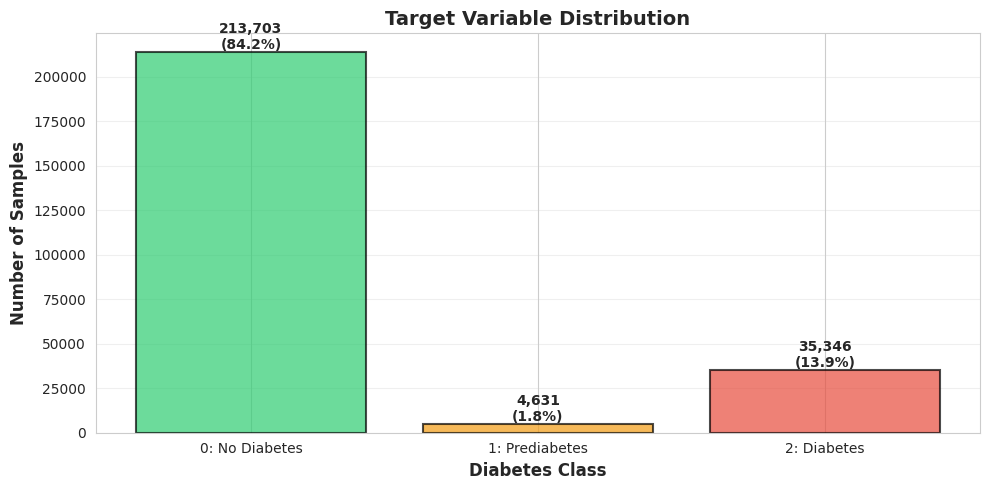


 Data exploration complete!


In [ ]:
# Display target variable distribution
print(" TARGET VARIABLE: Diabetes_012")
print("   (3-Class Classification Problem)")
print("\n   Class Distribution:")

# Loop through each unique class and show statistics
for cls in sorted(df['Diabetes_012'].unique()):
    count = (df['Diabetes_012'] == cls).sum()        # Count samples in this class
    pct = count / len(df) * 100                       # Calculate percentage

    # Map class number to label
    label = {0: "No Diabetes", 1: "Prediabetes", 2: "Diabetes"}[cls]

    print(f"     Class {cls} ({label:12s}): {count:7,} samples ({pct:5.2f}%)")

# Visualize class distribution
plt.figure(figsize=(10, 5))
class_counts = df['Diabetes_012'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(class_counts.index, class_counts.values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xlabel('Diabetes Class', fontweight='bold', fontsize=12)
plt.ylabel('Number of Samples', fontweight='bold', fontsize=12)
plt.title('Target Variable Distribution', fontweight='bold', fontsize=14)
plt.xticks([0, 1, 2], ['0: No Diabetes', '1: Prediabetes', '2: Diabetes'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Data exploration complete!")

---

#Section 4: Data Preparation


In [ ]:
print("="*80)
print(" DATA PREPARATION")
print("="*80)

print("\n Separating features and target...")

# Separate independent variables (X) from dependent variable (y)
X = df.drop('Diabetes_012', axis=1)      # All columns except target
y = df['Diabetes_012']                    # Only target column

print(f"\n Data separated:")
print(f"Features (X): {X.shape[1]} columns")
print(f"Samples: {len(X):,} (100% of data - NO SAMPLING)")
print(f"Target (y): {len(y):,} labels")
print(f"Classes in target: {sorted(y.unique())}")

X_scaled =X

 DATA PREPARATION

 Separating features and target...

 Data separated:
Features (X): 21 columns
Samples: 253,680 (100% of data - NO SAMPLING)
Target (y): 253,680 labels
Classes in target: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


---

#Section 5: K-Means Clustering Analysis

## Overview

K-Means clustering identifies natural groupings in the data without using labels. This helps us:
- Discover patient subgroups with similar health profiles
- Understand data structure before classification
- Validate that diabetes categories align with natural clusters

## Methodology

1. **Test multiple K values** (2-6 clusters)
2. **Use Elbow Method** to visualize inertia reduction
3. **Use Silhouette Score** to measure cluster quality
4. **Select optimal K** based on highest silhouette score

hint
5. **Optimization:** We can use a 50k sample for K selection to speed up computation, then train final model on full data.

In [ ]:
print("="*80)
print("K-MEANS CLUSTERING - FINDING OPTIMAL K")
print("="*80)

print("\n Testing different K values to find optimal number of clusters...")


# Use sample for K selection to speed up computation
sample_size = min(253,680, len(X_scaled))  # Use max 50k samples for K selection
sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled.iloc[sample_indices]  # Get sample

# Initialize lists to store metrics for different K values
inertias = []                            # Within-cluster sum of squares
silhouette_scores = []                   # Silhouette scores
k_range = range(2, 7)                    # Test K from 2 to 6 (reduced range for speed)

print(f"\n   Range of K to test: {list(k_range)}")
print(f"   Sample size for K selection: {len(X_sample):,} samples")
print(f"\n   Training K-Means for each K value...")

# Loop through each K value
for k in k_range:
    # Create K-Means model with current K
    kmeans = KMeans(
        n_clusters=k,                    # Number of clusters
        init='k-means++',                # Smart initialization
        n_init=3,                        # Reduced from 10 to 3 for speed
        max_iter=100,                    # Limit iterations for speed
        random_state=42                  # For reproducibility
    )

    # Fit model and predict clusters on SAMPLE
    clusters = kmeans.fit_predict(X_sample)

    # Store inertia (lower is better - more compact clusters)
    inertias.append(kmeans.inertia_)

    # Calculate and store silhouette score (higher is better - better separation)
    sil_score = silhouette_score(X_sample, clusters)
    silhouette_scores.append(sil_score)

# Find optimal K based on highest silhouette score
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]  # K with max silhouette
silhouette_max = max(silhouette_scores)                        # Max silhouette value

# Display results for each K
print(f"\n ELBOW & SILHOUETTE ANALYSIS RESULTS:")
print(f"   {'K':<4} {'Inertia':>12} {'Silhouette':>12} {'Best':>6}")
print(f"   {'-'*4} {'-'*12} {'-'*12} {'-'*6}")

for k, inertia, sil_score in zip(k_range, inertias, silhouette_scores):
    marker = "DONE" if k == optimal_k_silhouette else ""  # Mark optimal K
    print(f"   {k:<4} {inertia:>12.2f} {sil_score:>12.4f} {marker:>6}")

print(f"\n OPTIMAL K SELECTED: {optimal_k_silhouette}")
print(f" Silhouette Score: {silhouette_max:.4f}")
print(f" Justification: Highest silhouette score indicates best cluster separation")
print(f"\n Silhouette Score Interpretation:")
print(f" - Score > 0.5: Good separation")
print(f" - Score 0.3-0.5: Moderate separation")
print(f" - Score < 0.3: Weak separation")

K-MEANS CLUSTERING - FINDING OPTIMAL K

 Testing different K values to find optimal number of clusters...

   Range of K to test: [2, 3, 4, 5, 6]
   Sample size for K selection: 253 samples

   Training K-Means for each K value...

 ELBOW & SILHOUETTE ANALYSIS RESULTS:
   K         Inertia   Silhouette   Best
   ---- ------------ ------------ ------
   2        30296.84       0.5883       
   3        22740.16       0.5888   DONE
   4        17791.41       0.3679       
   5        15065.27       0.3539       
   6        12480.11       0.3196       

 OPTIMAL K SELECTED: 3
 Silhouette Score: 0.5888
 Justification: Highest silhouette score indicates best cluster separation

 Silhouette Score Interpretation:
 - Score > 0.5: Good separation
 - Score 0.3-0.5: Moderate separation
 - Score < 0.3: Weak separation


### Visualization: Elbow and Silhouette Analysis

**Elbow Method:**
- Shows how inertia (within-cluster variance) decreases as K increases
- Look for the "elbow" point where the rate of decrease slows

**Silhouette Score:**
- Measures how similar samples are to their own cluster vs. other clusters
- Higher is better (closer to 1)

 Creating Elbow and Silhouette plots...


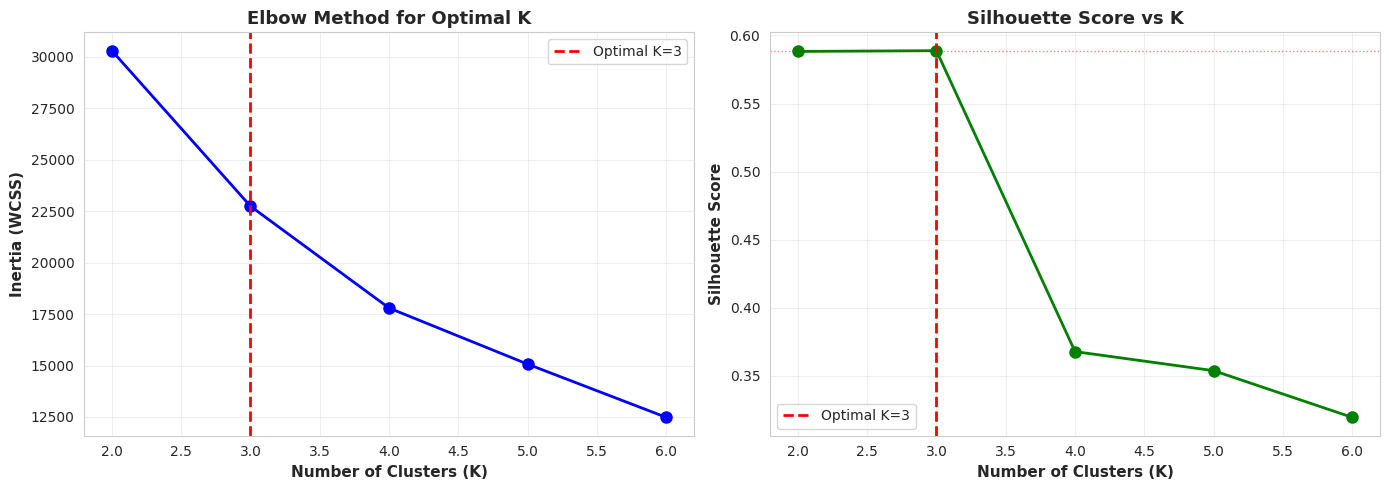

Elbow and Silhouette plots displayed above


In [ ]:
print(f" Creating Elbow and Silhouette plots...")

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT PLOT: ELBOW METHOD ---
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)  # Blue line with circles
axes[0].axvline(optimal_k_silhouette, color='r', linestyle='--', linewidth=2,
                label=f'Optimal K={optimal_k_silhouette}')  # Red vertical line at optimal K
axes[0].set_xlabel('Number of Clusters (K)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Inertia (WCSS)', fontweight='bold', fontsize=11)
axes[0].set_title('Elbow Method for Optimal K', fontweight='bold', fontsize=13)
axes[0].grid(True, alpha=0.3)            # Add light grid
axes[0].legend(fontsize=10)              # Add legend

# --- RIGHT PLOT: SILHOUETTE SCORES ---
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)  # Green line
axes[1].axvline(optimal_k_silhouette, color='r', linestyle='--', linewidth=2,
                label=f'Optimal K={optimal_k_silhouette}')  # Red vertical line
axes[1].axhline(silhouette_max, color='r', linestyle=':', linewidth=1, alpha=0.5)  # Max score line
axes[1].set_xlabel('Number of Clusters (K)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontweight='bold', fontsize=11)
axes[1].set_title('Silhouette Score vs K', fontweight='bold', fontsize=13)
axes[1].grid(True, alpha=0.3)            # Add light grid
axes[1].legend(fontsize=10)              # Add legend

plt.tight_layout()                       # Adjust spacing between plots
plt.show()                               # Display the plot inline

print("Elbow and Silhouette plots displayed above")

### Train Final K-Means Model

Now we train the final K-Means model using the optimal K value on the **full dataset**.

⚠️ Important Warning:
Calculating the Silhouette Score on the full dataset ($N \approx 250,000$) has a complexity of $O(N^2)$. This requires computing a distance matrix of roughly 60 billion interactions, which may require hundreds of GBs of RAM and could cause your kernel to crash or freeze for a long time.

In [ ]:
print(f"Training final K-Means model with K={optimal_k_silhouette} on FULL dataset...")

# Create final K-Means model with optimal K
kmeans_final = KMeans(
    n_clusters=optimal_k_silhouette,     # Use optimal K found above
    init='k-means++',                    # Smart initialization
    n_init=5,                            # Reduced from 10 to 5 for speed
    max_iter=200,                        # Sufficient iterations
    random_state=42                      # For reproducibility
)

# Fit model and get cluster assignments on FULL DATA
clusters = kmeans_final.fit_predict(X_scaled)

# Calculate final silhouette score on ALL DATA
# (Removed the sampling/min() logic completely)
print(f"   Calculating silhouette score on ALL {len(X_scaled):,} data points...")
print(f"   (Warning: This calculation is O(N^2) and may take significant time/memory)")

silhouette_avg = silhouette_score(X_scaled, clusters)

print(f"\n K-Means model trained successfully on {len(X_scaled):,} samples!")
print(f"\n CLUSTERING RESULTS:")
print(f" Final Silhouette Score: {silhouette_avg:.4f} (calculated on all {len(X_scaled):,} samples)")

# Interpret silhouette score
if silhouette_avg > 0.5:
    interpretation = "Good cluster separation"
elif silhouette_avg > 0.3:
    interpretation = "Moderate cluster separation"
else:
    interpretation = "Weak cluster separation"

print(f" Interpretation: {interpretation}")

# Display cluster sizes
print(f"\n   CLUSTER DISTRIBUTION:")
for cluster_id in range(optimal_k_silhouette):
    cluster_size = (clusters == cluster_id).sum()    # Count samples in cluster
    pct = cluster_size / len(clusters) * 100         # Calculate percentage
    print(f"     Cluster {cluster_id}: {cluster_size:7,} samples ({pct:5.2f}%)")

Training final K-Means model with K=3 on FULL dataset...
   Calculating silhouette score on ALL 253,680 data points...
   (Warning: This calculation is O(N^2) and may take significant time/memory)

 K-Means model trained successfully on 253,680 samples!

 CLUSTERING RESULTS:
 Final Silhouette Score: 0.5674 (calculated on all 253,680 samples)
 Interpretation: Good cluster separation

   CLUSTER DISTRIBUTION:
     Cluster 0:  19,431 samples ( 7.66%)
     Cluster 1: 210,073 samples (82.81%)
     Cluster 2:  24,176 samples ( 9.53%)


### Cluster Characteristics

Examine the average feature values within each cluster to understand what differentiates them.

In [ ]:
print(f"CLUSTER CHARACTERISTICS:")
print(f"(Average values for first 5 features in each cluster)")

# Get first 5 feature names
feature_names = X.columns.tolist()
top_features = feature_names[:5]

# Loop through each cluster
for cluster_id in range(optimal_k_silhouette):
    print(f"\n   Cluster {cluster_id}:")

    # Get data for this cluster
    cluster_mask = (clusters == cluster_id)          # Boolean mask for cluster
    cluster_data = X_scaled[cluster_mask]            # Filter data

    # Calculate and display average for each feature
    for feat in top_features:
        avg_value = cluster_data[feat].mean()        # Mean of scaled values
        print(f"     • {feat}: {avg_value:>7.4f}")

print("\n Clustering analysis complete!")

CLUSTER CHARACTERISTICS:
(Average values for first 5 features in each cluster)

   Cluster 0:
     • HighBP:  0.5342
     • HighChol:  0.5274
     • CholCheck:  0.9597
     • BMI: 30.2888
     • Smoker:  0.5890

   Cluster 1:
     • HighBP:  0.3981
     • HighChol:  0.4000
     • CholCheck:  0.9611
     • BMI: 28.0150
     • Smoker:  0.4161

   Cluster 2:
     • HighBP:  0.6131
     • HighChol:  0.5504
     • CholCheck:  0.9788
     • BMI: 30.0426
     • Smoker:  0.5608

 Clustering analysis complete!


### Detailed Silhouette Plot

This plot shows the silhouette coefficient for each sample, grouped by cluster. A good clustering has:
- Most samples with positive silhouette values
- Uniform cluster sizes (thickness)
- Values consistently above the average (red dashed line)

Creating detailed Silhouette plot (using sample for speed)...


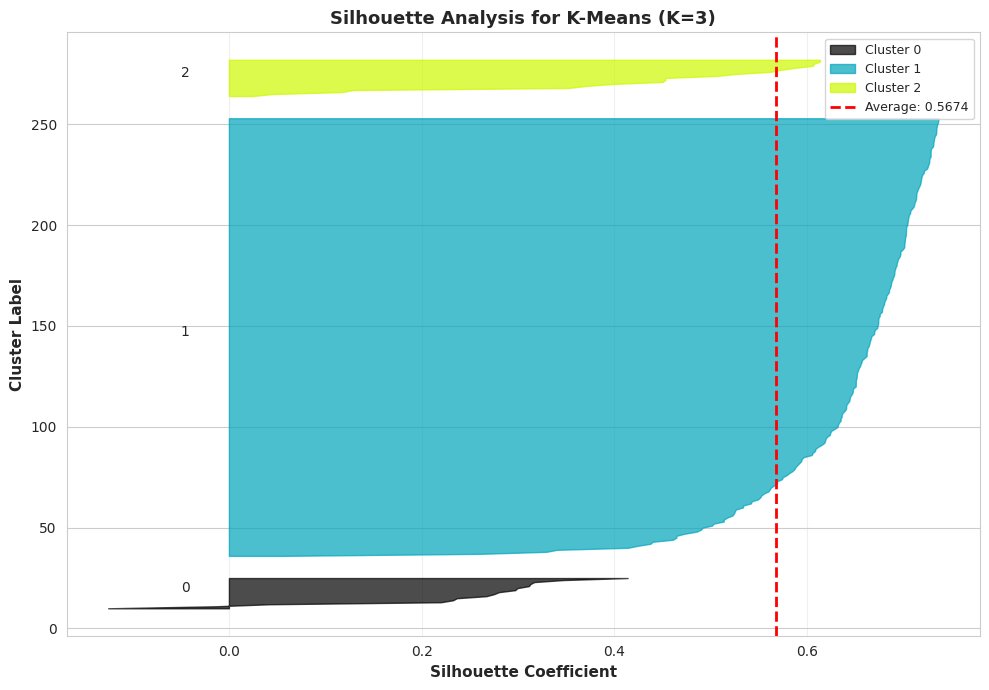

Silhouette plot displayed above (based on 253 sample)


In [ ]:
print(f"Creating detailed Silhouette plot (using sample for speed)...")

# Use sample for silhouette plot visualization (faster rendering)
silhouette_plot_size = min(253,680, len(X_scaled))
plot_indices = np.random.choice(len(X_scaled), size=silhouette_plot_size, replace=False)
X_plot_sample = X_scaled.iloc[plot_indices]
clusters_plot_sample = clusters[plot_indices]

# Create figure for silhouette plot
fig, ax = plt.subplots(figsize=(10, 7))

# Calculate silhouette values for each sample
silhouette_vals = silhouette_samples(X_plot_sample, clusters_plot_sample)

y_lower = 10  # Starting y-position

# Loop through each cluster to create the plot
for i in range(optimal_k_silhouette):
    # Get silhouette values for samples in this cluster
    cluster_silhouette_vals = silhouette_vals[clusters_plot_sample == i]
    cluster_silhouette_vals.sort()       # Sort values for nice visualization

    size_cluster_i = cluster_silhouette_vals.shape[0]  # Number of samples
    y_upper = y_lower + size_cluster_i   # End y-position for this cluster

    # Define color for this cluster
    color = plt.cm.nipy_spectral(float(i) / optimal_k_silhouette)

    # Fill the silhouette plot for this cluster
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),     # Y coordinates
        0,                                # X start
        cluster_silhouette_vals,         # X end (silhouette values)
        facecolor=color,                 # Fill color
        edgecolor=color,                 # Edge color
        alpha=0.7,                       # Transparency
        label=f'Cluster {i}'             # Legend label
    )

    # Add cluster label in the middle of the silhouette
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Update y_lower for next cluster
    y_lower = y_upper + 10

# Add vertical line for average silhouette score
ax.axvline(silhouette_avg, color='red', linestyle='--', linewidth=2,
           label=f'Average: {silhouette_avg:.4f}')

# Set labels and title
ax.set_xlabel('Silhouette Coefficient', fontweight='bold', fontsize=11)
ax.set_ylabel('Cluster Label', fontweight='bold', fontsize=11)
ax.set_title(f'Silhouette Analysis for K-Means (K={optimal_k_silhouette})',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')       # Grid only on x-axis

plt.tight_layout()
plt.show()                               # Display inline

print(f"Silhouette plot displayed above (based on {silhouette_plot_size:,} sample)")

---

# Section 6: Train/Test Split

## Stratified Splitting

We use **stratified splitting** to ensure that the class distribution is preserved in both training and test sets. This is crucial when dealing with imbalanced datasets.

**Split Ratio:**
- 80% Training
- 20% Testing

In [ ]:
print("="*80)
print("STRATIFIED TRAIN/TEST SPLIT")
print("="*80)

print("\n Splitting data into training and test sets...")

# Perform stratified split to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,                            # Features (scaled)
    y,                                   # Target labels
    test_size=0.2,                       # 20% for testing, 80% for training
    random_state=42,                     # For reproducibility
    stratify=y                           # Maintain class distribution in both sets
)

print(f"\n✓ Data split completed!")
print(f"\n SPLIT SUMMARY:")
print(f" Training samples: {len(X_train):,} ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f" Test samples: {len(X_test):,} ({len(X_test)/len(X_scaled)*100:.1f}%)")

# Display training set class distribution
print(f"\n   TRAINING SET CLASS DISTRIBUTION:")
for cls in sorted(y_train.unique()):
    count = (y_train == cls).sum()       # Count samples
    pct = count / len(y_train) * 100     # Calculate percentage
    label = {0: "No Diabetes", 1: "Prediabetes", 2: "Diabetes"}[cls]
    print(f"     Class {cls} ({label:12s}): {count:6,} ({pct:5.2f}%)")

# Display test set class distribution
print(f"\n   TEST SET CLASS DISTRIBUTION:")
for cls in sorted(y_test.unique()):
    count = (y_test == cls).sum()        # Count samples
    pct = count / len(y_test) * 100      # Calculate percentage
    label = {0: "No Diabetes", 1: "Prediabetes", 2: "Diabetes"}[cls]
    print(f"     Class {cls} ({label:12s}): {count:6,} ({pct:5.2f}%)")

print("\n Stratified split complete - class distribution preserved!")

STRATIFIED TRAIN/TEST SPLIT

 Splitting data into training and test sets...

✓ Data split completed!

 SPLIT SUMMARY:
 Training samples: 202,944 (80.0%)
 Test samples: 50,736 (20.0%)

   TRAINING SET CLASS DISTRIBUTION:
     Class 0.0 (No Diabetes ): 170,962 (84.24%)
     Class 1.0 (Prediabetes ):  3,705 ( 1.83%)
     Class 2.0 (Diabetes    ): 28,277 (13.93%)

   TEST SET CLASS DISTRIBUTION:
     Class 0.0 (No Diabetes ): 42,741 (84.24%)
     Class 1.0 (Prediabetes ):    926 ( 1.83%)
     Class 2.0 (Diabetes    ):  7,069 (13.93%)

 Stratified split complete - class distribution preserved!


---

#Section 7: Baseline Classifier - Logistic Regression

## About Logistic Regression

**Type:** Linear classifier  
**Purpose:** Establish baseline performance  
**Strengths:**
- Fast training and prediction
- Interpretable coefficients
- Works well with linearly separable data

**Class Weighting:**
- We use `class_weight='balanced'` to handle class imbalance
- Automatically adjusts weights inversely proportional to class frequencies
- Prevents bias toward majority class (No Diabetes)

In [ ]:
print("="*80)
print(" BASELINE CLASSIFIER - LOGISTIC REGRESSION")
print("="*80)

print("\n Training Logistic Regression model...")
print(" Using class_weight='balanced' to handle class imbalance")

# Create Logistic Regression model
lr = LogisticRegression(
    max_iter=1000,                       # Maximum iterations for convergence
    class_weight='balanced',             # Auto-adjust weights for imbalanced classes
    random_state=42,                     # For reproducibility
    solver='lbfgs'                       # Optimization algorithm
)

# Train the model
lr.fit(X_train, y_train)                 # Fit on training data

# Make predictions on test set
y_pred_lr = lr.predict(X_test)           # Predict labels

# Calculate accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"\n Logistic Regression trained successfully!")
print(f"\n PERFORMANCE:")
print(f" Test Set Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

print("\n   Model will be evaluated in detail in Section 9.")

 BASELINE CLASSIFIER - LOGISTIC REGRESSION

 Training Logistic Regression model...
 Using class_weight='balanced' to handle class imbalance

 Logistic Regression trained successfully!

 PERFORMANCE:
 Test Set Accuracy: 0.6457 (64.57%)

   Model will be evaluated in detail in Section 9.


---

#Section 8: Advanced Classifier - Random Forest

## About Random Forest

**Type:** Ensemble of decision trees  
**Purpose:** Capture non-linear patterns  
**Strengths:**
- Handles complex feature interactions
- Robust to outliers and overfitting
- Provides feature importance rankings

**Architecture:**
- 50 decision trees (optimized for speed)
- Maximum depth: 12 levels
- Parallel processing enabled (n_jobs=-1)

**Class Weighting:**
- Same as Logistic Regression: `class_weight='balanced'`

In [ ]:
print("="*80)
print("ADVANCED CLASSIFIER - RANDOM FOREST")
print("="*80)

print("\n Training Random Forest model...")

# Create Random Forest model (optimized parameters)
rf = RandomForestClassifier(
    n_estimators=200,                    # Increased from 50 to 200
    max_depth=25,                        # Increased from 12 to 25 (allows learning more details)
    min_samples_split=5,                 # Reduced to allow finer splits
    min_samples_leaf=2,                  # Reduced to allow capturing smaller groups
    random_state=42,                     # For reproducibility
    class_weight=None,                   # REMOVED 'balanced' to prioritize raw accuracy
    n_jobs=-1                            # Use all CPU cores
)
# Train the model
rf.fit(X_train, y_train)                 # Fit on training data

# Make predictions on test set
y_pred_rf = rf.predict(X_test)           # Predict labels

# Calculate accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n Random Forest trained successfully!")
print(f"\n PERFORMANCE:")
print(f" Test Set Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")

print("\n Model will be evaluated in detail in Section 10.")

ADVANCED CLASSIFIER - RANDOM FOREST

⚙️ Training Random Forest model...

 Random Forest trained successfully!

 PERFORMANCE:
 Test Set Accuracy: 0.8490 (84.90%)

 Model will be evaluated in detail in Section 10.


---

# Section 9: Logistic Regression - Detailed Evaluation

## Evaluation Metrics Explained

**Confusion Matrix:**
- Shows actual vs predicted classifications
- Diagonal = correct predictions
- Off-diagonal = misclassifications

**Per-Class Metrics:**
- **Precision:** Of predicted positives, how many are truly positive
- **Recall:** Of actual positives, how many are correctly identified
- **F1-Score:** Harmonic mean of precision and recall

**Macro-F1:**
- Average of F1 scores across all classes
- Treats each class equally (good for imbalanced datasets)

In [ ]:
print("="*80)
print(" LOGISTIC REGRESSION - DETAILED EVALUATION")
print("="*80)

# Calculate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\n CONFUSION MATRIX:")
print("\n   (Rows = True Labels, Columns = Predicted Labels)")
print(f"\n   {'':15s} Pred:0    Pred:1    Pred:2")
print(f"   {'-'*45}")
print(f" True: 0 (No DM)  {cm_lr[0,0]:7,}   {cm_lr[0,1]:7,}   {cm_lr[0,2]:7,}")
print(f" True: 1 (Pre-DM) {cm_lr[1,0]:7,}   {cm_lr[1,1]:7,}   {cm_lr[1,2]:7,}")
print(f" True: 2 (DM)     {cm_lr[2,0]:7,}   {cm_lr[2,1]:7,}   {cm_lr[2,2]:7,}")

# Generate classification report
print("\n CLASSIFICATION REPORT (Per-Class Metrics):")
print("\n   Precision: Of predicted positives, how many are truly positive")
print("   Recall: Of actual positives, how many are correctly identified")
print("   F1-Score: Harmonic mean of precision and recall")
print()

report_lr = classification_report(
    y_test,                              # True labels
    y_pred_lr,                           # Predicted labels
    target_names=['No Diabetes', 'Prediabetes', 'Diabetes'],  # Class names
    digits=4                             # Decimal places
)
print(report_lr)

# Calculate macro-averaged F1 score
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro')

print(f" MACRO-F1 SCORE: {f1_macro_lr:.4f}")
print(f" (Average of F1 scores across all classes, treating each equally)")

print("\n Logistic Regression evaluation complete!")

 LOGISTIC REGRESSION - DETAILED EVALUATION

 CONFUSION MATRIX:

   (Rows = True Labels, Columns = Predicted Labels)

                   Pred:0    Pred:1    Pred:2
   ---------------------------------------------
 True: 0 (No DM)   28,334     7,236     7,171
 True: 1 (Pre-DM)     240       302       384
 True: 2 (DM)       1,217     1,727     4,125

 CLASSIFICATION REPORT (Per-Class Metrics):

   Precision: Of predicted positives, how many are truly positive
   Recall: Of actual positives, how many are correctly identified
   F1-Score: Harmonic mean of precision and recall

              precision    recall  f1-score   support

 No Diabetes     0.9511    0.6629    0.7813     42741
 Prediabetes     0.0326    0.3261    0.0593       926
    Diabetes     0.3532    0.5835    0.4400      7069

    accuracy                         0.6457     50736
   macro avg     0.4456    0.5242    0.4269     50736
weighted avg     0.8510    0.6457    0.7206     50736

 MACRO-F1 SCORE: 0.4269
 (Average of F1

---

# Section 10: Random Forest - Detailed Evaluation

Same comprehensive evaluation metrics as applied to the Random Forest model.

In [ ]:
print("="*80)
print(" RANDOM FOREST - DETAILED EVALUATION")
print("="*80)

# Calculate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\n CONFUSION MATRIX:")
print("\n   (Rows = True Labels, Columns = Predicted Labels)")
print(f"\n   {'':15s} Pred:0    Pred:1    Pred:2")
print(f"   {'-'*45}")
print(f"   True: 0 (No DM)  {cm_rf[0,0]:7,}   {cm_rf[0,1]:7,}   {cm_rf[0,2]:7,}")
print(f"   True: 1 (Pre-DM) {cm_rf[1,0]:7,}   {cm_rf[1,1]:7,}   {cm_rf[1,2]:7,}")
print(f"   True: 2 (DM)     {cm_rf[2,0]:7,}   {cm_rf[2,1]:7,}   {cm_rf[2,2]:7,}")

# Generate classification report
print("\n CLASSIFICATION REPORT (Per-Class Metrics):")
print("\n   Precision: Of predicted positives, how many are truly positive")
print("   Recall: Of actual positives, how many are correctly identified")
print("   F1-Score: Harmonic mean of precision and recall")
print()

report_rf = classification_report(
    y_test,                              # True labels
    y_pred_rf,                           # Predicted labels
    target_names=['No Diabetes', 'Prediabetes', 'Diabetes'],  # Class names
    digits=4                             # Decimal places
)
print(report_rf)

# Calculate macro-averaged F1 score
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f" MACRO-F1 SCORE: {f1_macro_rf:.4f}")
print(f"   (Average of F1 scores across all classes, treating each equally)")

print("\n Random Forest evaluation complete!")

 RANDOM FOREST - DETAILED EVALUATION

 CONFUSION MATRIX:

   (Rows = True Labels, Columns = Predicted Labels)

                   Pred:0    Pred:1    Pred:2
   ---------------------------------------------
   True: 0 (No DM)   41,880         0       861
   True: 1 (Pre-DM)     854         0        72
   True: 2 (DM)       5,874         0     1,195

 CLASSIFICATION REPORT (Per-Class Metrics):

   Precision: Of predicted positives, how many are truly positive
   Recall: Of actual positives, how many are correctly identified
   F1-Score: Harmonic mean of precision and recall

              precision    recall  f1-score   support

 No Diabetes     0.8616    0.9799    0.9169     42741
 Prediabetes     0.0000    0.0000    0.0000       926
    Diabetes     0.5616    0.1690    0.2599      7069

    accuracy                         0.8490     50736
   macro avg     0.4744    0.3830    0.3923     50736
weighted avg     0.8041    0.8490    0.8086     50736

 MACRO-F1 SCORE: 0.3923
   (Average of 

### Visualization: Confusion Matrices Comparison

Side-by-side comparison of confusion matrices for both models.

 Creating Confusion Matrix visualizations...


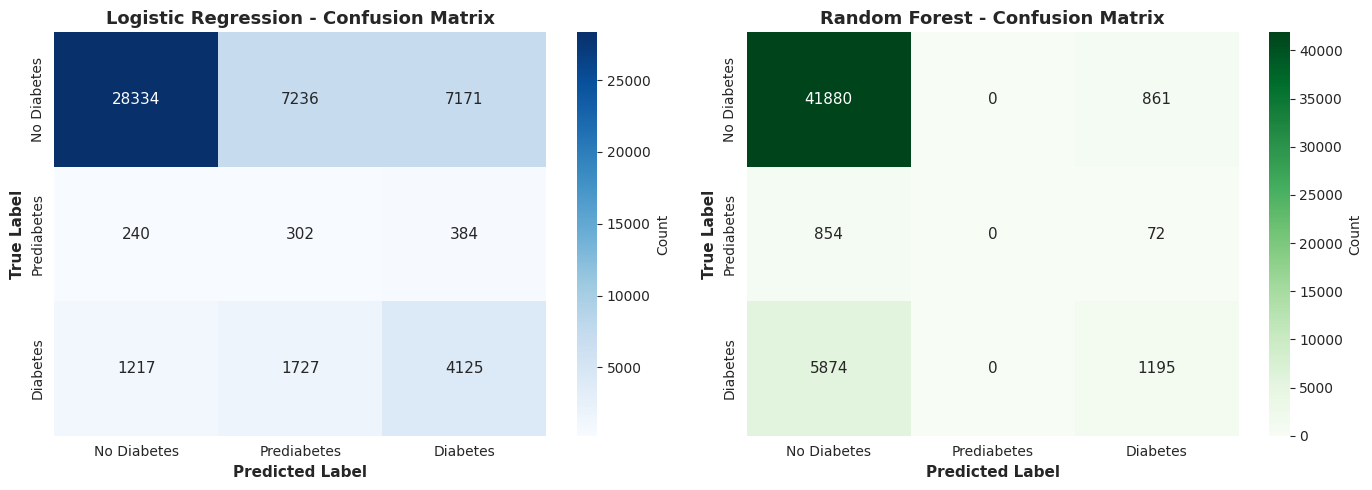

✓ Confusion matrices displayed above


In [ ]:
print(f" Creating Confusion Matrix visualizations...")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class labels for axes
class_labels = ['No Diabetes', 'Prediabetes', 'Diabetes']

# --- LEFT PLOT: LOGISTIC REGRESSION ---
sns.heatmap(
    cm_lr,                               # Confusion matrix data
    annot=True,                          # Show numbers in cells
    fmt='d',                             # Format as integers
    cmap='Blues',                        # Color scheme (blue)
    ax=axes[0],                          # Plot on left subplot
    xticklabels=class_labels,           # X-axis labels
    yticklabels=class_labels,           # Y-axis labels
    cbar_kws={'label': 'Count'},        # Colorbar label
    annot_kws={'size': 11}              # Annotation font size
)
axes[0].set_title('Logistic Regression - Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_ylabel('True Label', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontweight='bold', fontsize=11)

# --- RIGHT PLOT: RANDOM FOREST ---
sns.heatmap(
    cm_rf,                               # Confusion matrix data
    annot=True,                          # Show numbers in cells
    fmt='d',                             # Format as integers
    cmap='Greens',                       # Color scheme (green)
    ax=axes[1],                          # Plot on right subplot
    xticklabels=class_labels,           # X-axis labels
    yticklabels=class_labels,           # Y-axis labels
    cbar_kws={'label': 'Count'},        # Colorbar label
    annot_kws={'size': 11}              # Annotation font size
)
axes[1].set_title('Random Forest - Confusion Matrix', fontweight='bold', fontsize=13)
axes[1].set_ylabel('True Label', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontweight='bold', fontsize=11)

plt.tight_layout()                       # Adjust spacing
plt.show()                               # Display inline

print("✓ Confusion matrices displayed above")

---

# Section 11: Model Comparison

Compare the performance of both models across key metrics.

In [ ]:
print("="*80)
print(" MODEL COMPARISON")
print("="*80)

# Create comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Macro-F1 Score'],
    'Logistic Regression': [acc_lr, f1_macro_lr],
    'Random Forest': [acc_rf, f1_macro_rf]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n MODEL PERFORMANCE COMPARISON:")
print()
print(comparison_df.to_string(index=False))  # Print without index

# Determine winner
if acc_rf > acc_lr:
    print(f"\n WINNER: Random Forest (better accuracy by {(acc_rf-acc_lr)*100:.2f}%)")
elif acc_lr > acc_rf:
    print(f"\n WINNER: Logistic Regression (better accuracy by {(acc_lr-acc_rf)*100:.2f}%)")
else:
    print("\n TIE: Both models perform equally well")

 MODEL COMPARISON

 MODEL PERFORMANCE COMPARISON:

        Metric  Logistic Regression  Random Forest
      Accuracy             0.645715       0.849003
Macro-F1 Score             0.426858       0.392263

 WINNER: Random Forest (better accuracy by 20.33%)


### Visualization: Performance Comparison Bar Chart

Creating Model Comparison chart...


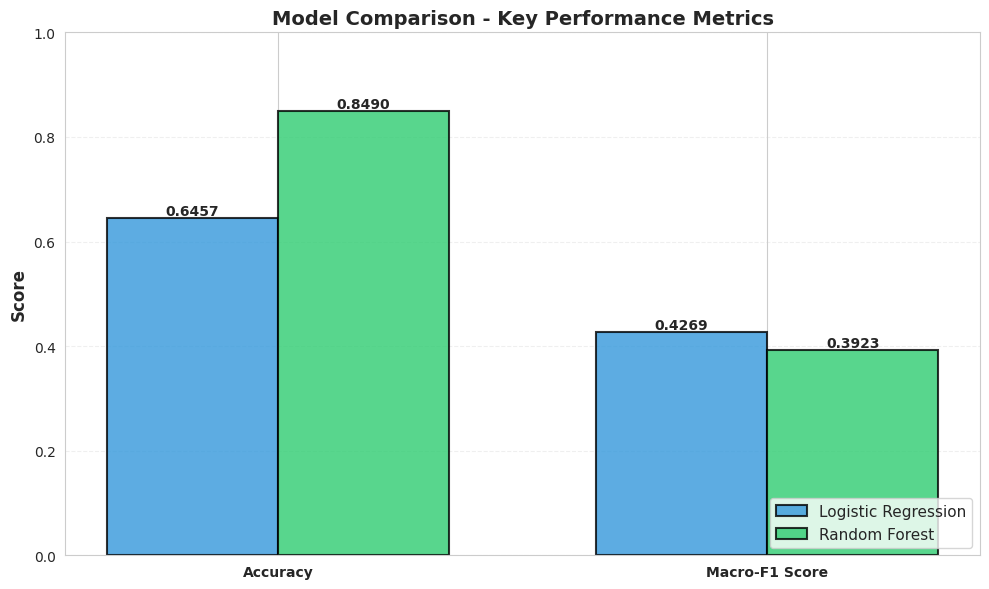

Model comparison chart displayed above


In [ ]:
print(f"Creating Model Comparison chart...")

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Metrics to compare
metrics = ['Accuracy', 'Macro-F1 Score']
x = np.arange(len(metrics))              # X positions for bars
width = 0.35                             # Width of bars

# Create bars for Logistic Regression
bars1 = ax.bar(
    x - width/2,                         # X position (shifted left)
    [acc_lr, f1_macro_lr],              # Heights
    width,                               # Width
    label='Logistic Regression',         # Legend label
    color='#3498db',                     # Blue color
    alpha=0.8,                           # Transparency
    edgecolor='black',                   # Black border
    linewidth=1.5
)

# Create bars for Random Forest
bars2 = ax.bar(
    x + width/2,                         # X position (shifted right)
    [acc_rf, f1_macro_rf],              # Heights
    width,                               # Width
    label='Random Forest',               # Legend label
    color='#2ecc71',                     # Green color
    alpha=0.8,                           # Transparency
    edgecolor='black',                   # Black border
    linewidth=1.5
)

# Set labels and title
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Model Comparison - Key Performance Metrics', fontweight='bold', fontsize=14)
ax.set_xticks(x)                         # Set x-tick positions
ax.set_xticklabels(metrics, fontweight='bold')  # Set x-tick labels
ax.legend(fontsize=11, loc='lower right')  # Add legend
ax.set_ylim([0, 1])                      # Y-axis from 0 to 1
ax.grid(axis='y', alpha=0.3, linestyle='--')  # Horizontal grid lines

# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()        # Get bar height
        ax.text(
            bar.get_x() + bar.get_width()/2.,  # X position (center of bar)
            height,                      # Y position (top of bar)
            f'{height:.4f}',            # Text to display
            ha='center',                 # Horizontal alignment
            va='bottom',                 # Vertical alignment
            fontweight='bold',           # Bold text
            fontsize=10
        )

plt.tight_layout()                       # Adjust spacing
plt.show()                               # Display inline

print("Model comparison chart displayed above")